#**💊 Мини‑таск: Отбор молекул‑хитов**
После запуска генеративной модели на практике вы получили множество молекул, потенциально активных в отношении эстрогенового рецептора α (Estrogen Receptor Alpha, ERα, также известен как ESR1). Ваша задача - провести фильтрацию и отбор лучших кандидатов по ключевым параметрам, которые важны для разработки препаратов.

Этот мини‑таск продолжает задачу предыдущего этапа, где вы обучали регрессионную модель для предсказания биологической активности (pValue) на основе молекулярных признаков.

#**🎯 Цель**
Выделить из сгенерированного набора молекулы‑хиты, которые:

* валидны (корректный SMILES, можно обработать через RDKit),
* потенциально активны (по предсказанию регрессионной модели pValue),
#**удовлетворяют ключевым требованиям:**
* drug-likeness (QED);
* синтезируемость (SA Score);
* проходимость через гематоэнцефалический барьер (BBB);
* низкая токсичность (отсутствие токсофоров);
* соответствие правилам Липинского.
**✅ Что нужно сделать**
#**1. Проверить валидность SMILES**
Проверьте, что молекулы читаются через RDKit. Исключите невалидные строки.

#**2. Предсказать активность (pValue)**
Используйте регрессионную модель, которую вы обучили ранее, чтобы предсказать значение pValue для каждой молекулы. Отберите молекулы, у которых:

* pValue > 6.0   # Активность выше пороговой


Напоминание: pValue — это обобщённое логарифмическое значение активности: pKi = –log₁₀(Ki), pIC₅₀ = –log₁₀(IC₅₀), pEC₅₀ = –log₁₀(EC₅₀)

#**3. Рассчитать ключевые свойства**
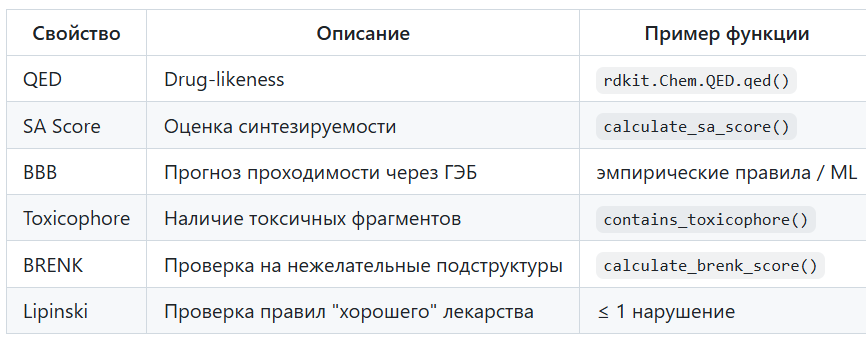
#**4. 🔍 Отобрать молекулы‑хиты**
Сформируйте финальный список молекул, которые удовлетворяют следующим условиям:

* pValue > 6.0;
* QED > 0.7; (или 0.5 на крайний случай)
* 2 < SA Score < 6;
* BBB-проходимость положительная (по модели или правилу);
* нет токсофоров (по BRENK или RDKit);
* не более 1 нарушения правил Липинского.


Для начала импортируем необходимые библиотеки

In [33]:
!pip install rdkit lightgbm pandas numpy tqdm molvs

In [34]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import QED, Descriptors, Lipinski, rdFingerprintGenerator
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
import lightgbm as lgb
from tqdm import tqdm
import joblib
from rdkit.Chem import Draw
from math import ceil
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

tqdm.pandas()

Теперь мы загрузим из гугл диска наш датасет с 99 сгенерированными на практике молекулами и нашу модель (LightGBM).

In [35]:
molecules = pd.read_csv('/content/sampling.csv')  # Наш файл с SMILES

# Загрузка обученной модели LightGBM
model = joblib.load('/content/LGBM.pkl')
molecules

,SMILES,NLL
0,COC(=O)c1coc(CN2CCN(C(=O)Cc3ccc4c(c3)OCO4)CC2)n1,27.04
1,Cc1ccc(NC(=O)c2ccc(OCCC(F)(F)F)nc2)cc1C(=O)N1C...,34.59
2,O=C(N=c1[nH]c(CN2CCOCC2)cs1)Nc1ccccc1,24.74
3,Cc1ccc(S(=O)(=O)N2CCN3CCCCC3C2)s1,26.09
4,CCC(c1ccc([S+](C)[O-])cc1)c1c(C)nc2sc3c(c2c1-c...,33.82
...,...,...
94,Cc1ccc(NC(=O)OCc2c(C)noc2C)cc1,22.01
95,CCN(CC)C1CCN(Cc2n[nH]c(=O)[nH]2)C1,29.31
96,CCN(CC)CCCNC(=O)c1c(NC(=O)c2ccc(OC)cc2)sc2c1CC...,31.84
97,CCOC(=O)C1c2c(ccc3ccccc23)OC2Nc3cc(C)c(C)cc3N21,33.73


NLL — это метрика генеративной модели. Она показывает "правдоподобность" сгенерированных молекул. Так нам инетресен показатель биологической активности, то мы можем удалить колонку с NLL.

In [36]:
molecules=molecules.drop(columns='NLL')
molecules

,SMILES
0,COC(=O)c1coc(CN2CCN(C(=O)Cc3ccc4c(c3)OCO4)CC2)n1
1,Cc1ccc(NC(=O)c2ccc(OCCC(F)(F)F)nc2)cc1C(=O)N1C...
2,O=C(N=c1[nH]c(CN2CCOCC2)cs1)Nc1ccccc1
3,Cc1ccc(S(=O)(=O)N2CCN3CCCCC3C2)s1
4,CCC(c1ccc([S+](C)[O-])cc1)c1c(C)nc2sc3c(c2c1-c...
...,...
94,Cc1ccc(NC(=O)OCc2c(C)noc2C)cc1
95,CCN(CC)C1CCN(Cc2n[nH]c(=O)[nH]2)C1
96,CCN(CC)CCCNC(=O)c1c(NC(=O)c2ccc(OC)cc2)sc2c1CC...
97,CCOC(=O)C1c2c(ccc3ccccc23)OC2Nc3cc(C)c(C)cc3N21


Начальным этапом будет проверка SMILES на валидность

In [37]:
def is_valid_smiles(smiles):
    """Проверяет валидность SMILES строки"""
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

In [38]:
molecules['is_valid'] = molecules['SMILES'].progress_apply(is_valid_smiles)
valid_mols = molecules[molecules['is_valid']].copy()
print(f"Валидных молекул: {len(valid_mols)}/{len(molecules)}")

100%|██████████| 99/99 [00:00<00:00, 522.61it/s]

Валидных молекул: 99/99


Мы видим, что все SMILES посчитаны как валидные. Для чистоты эксперимента построим изображения этих молекул

In [39]:
def visualize_all_molecules(df, smiles_col='SMILES', mols_per_page=20, img_size=(300, 200)):
    """
    Визуализирует все молекулы из датасета с разбивкой по страницам

    Параметры:
    - df: DataFrame с молекулами
    - smiles_col: название колонки с SMILES
    - mols_per_page: количество молекул на одной странице
    - img_size: размер изображения для каждой молекулы
    """
    # Конвертируем все SMILES в молекулы
    mols = []
    valid_smiles = []
    for smiles in df[smiles_col]:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            mols.append(mol)
            valid_smiles.append(smiles)
        else:
            print(f"Невалидный SMILES: {smiles}")

    total_mols = len(mols)
    num_pages = ceil(total_mols / mols_per_page)

    for page in range(num_pages):
        start_idx = page * mols_per_page
        end_idx = min((page + 1) * mols_per_page, total_mols)

        print(f"\nСтраница {page + 1}/{num_pages} (молекулы {start_idx + 1}-{end_idx})")

        # Создаем grid изображений
        img = Draw.MolsToGridImage(
            mols[start_idx:end_idx],
            legends=[f"{i+1}. {valid_smiles[i][:20]}" for i in range(start_idx, end_idx)],
            molsPerRow=5,
            subImgSize=img_size,
            returnPNG=False  # Важно: возвращаем PIL.Image вместо байтов
        )

        # Сохраняем изображение
        img_path = f"molecules_page_{page+1}.png"
        img.save(img_path)
        print(f"Сохранено: {img_path}")

        # Отображаем в ноутбуке
        display(img)

    print(f"\nВсего визуализировано {total_mols} валидных молекул")


Страница 1/4 (молекулы 1-25)
Сохранено: molecules_page_1.png


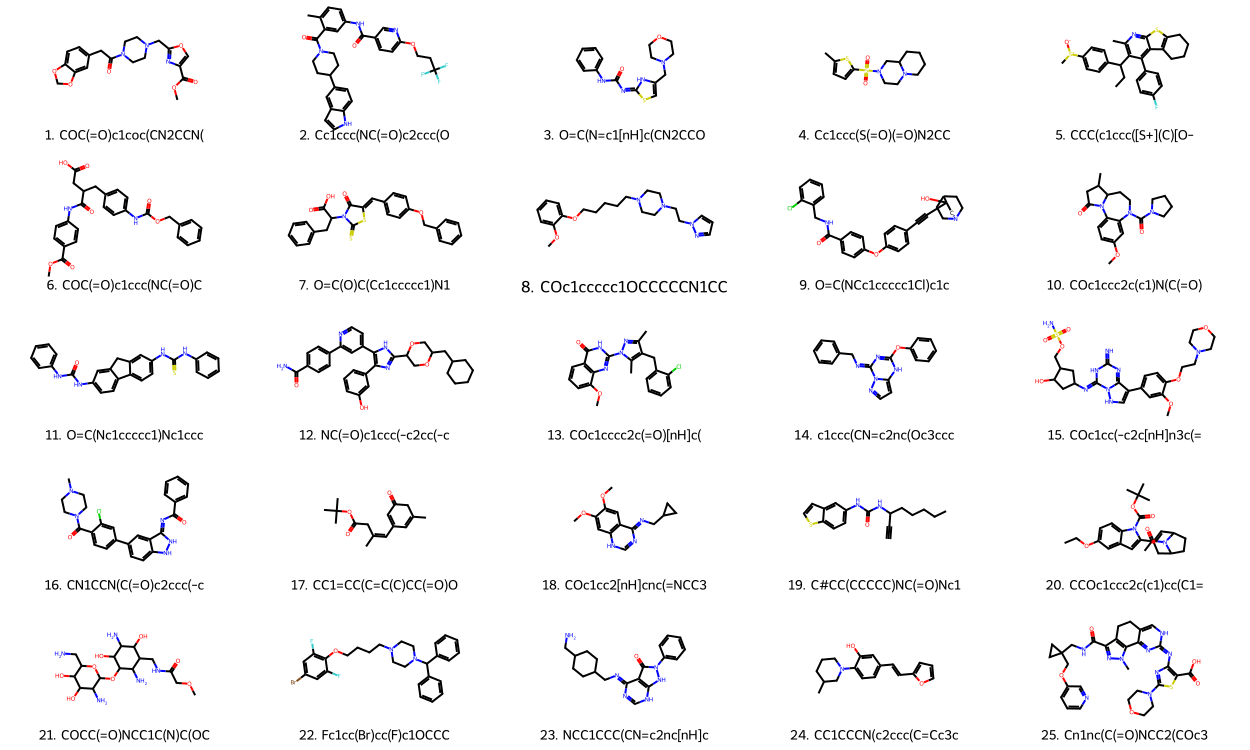


Страница 2/4 (молекулы 26-50)
Сохранено: molecules_page_2.png


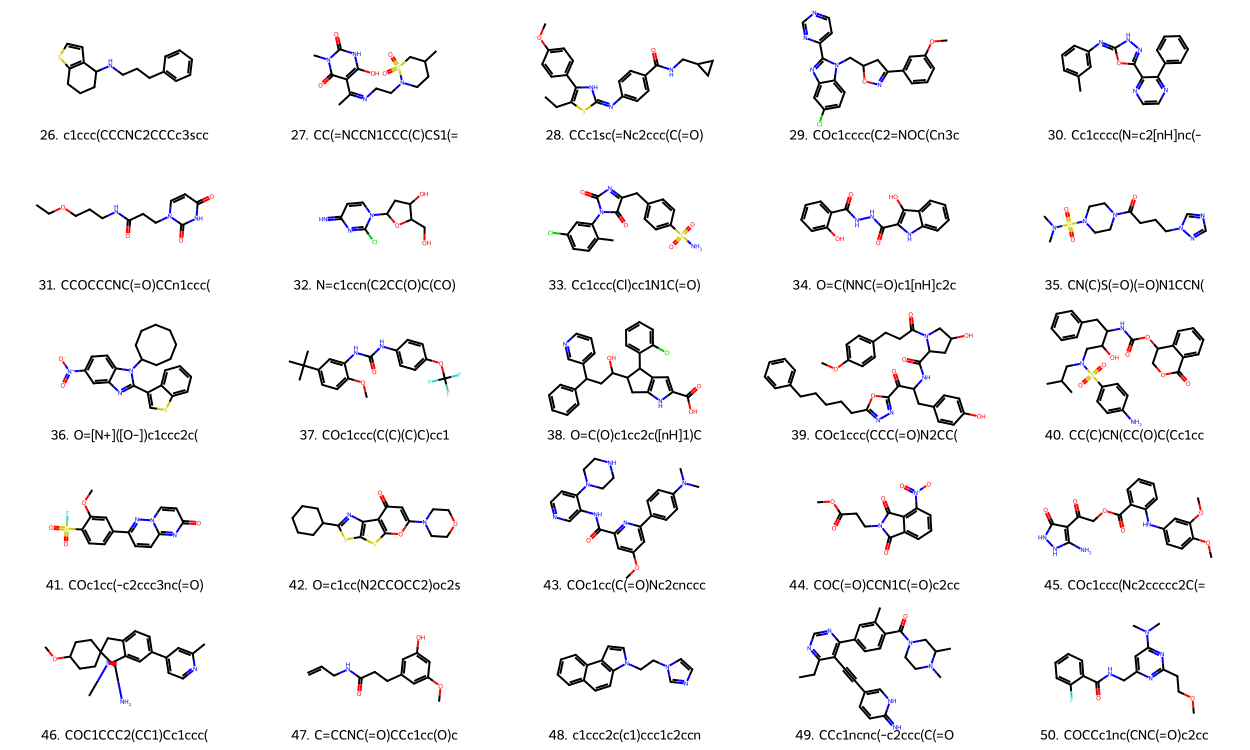


Страница 3/4 (молекулы 51-75)
Сохранено: molecules_page_3.png


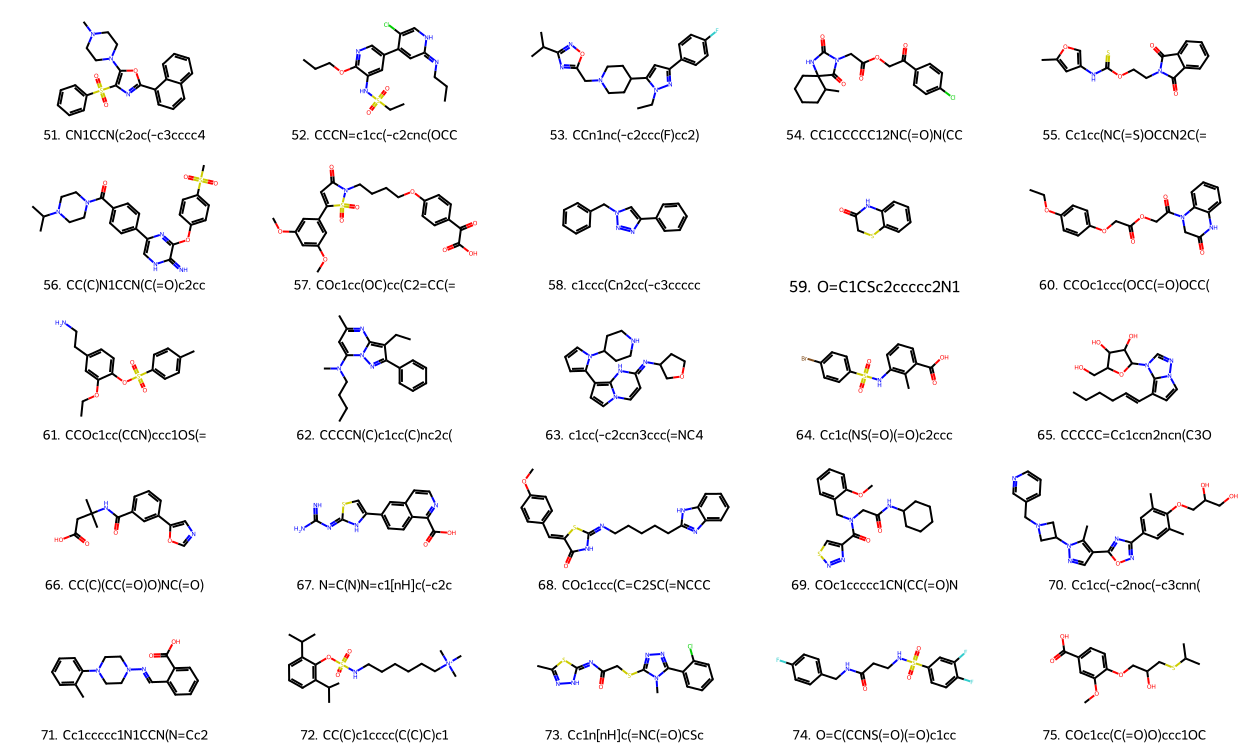


Страница 4/4 (молекулы 76-99)
Сохранено: molecules_page_4.png


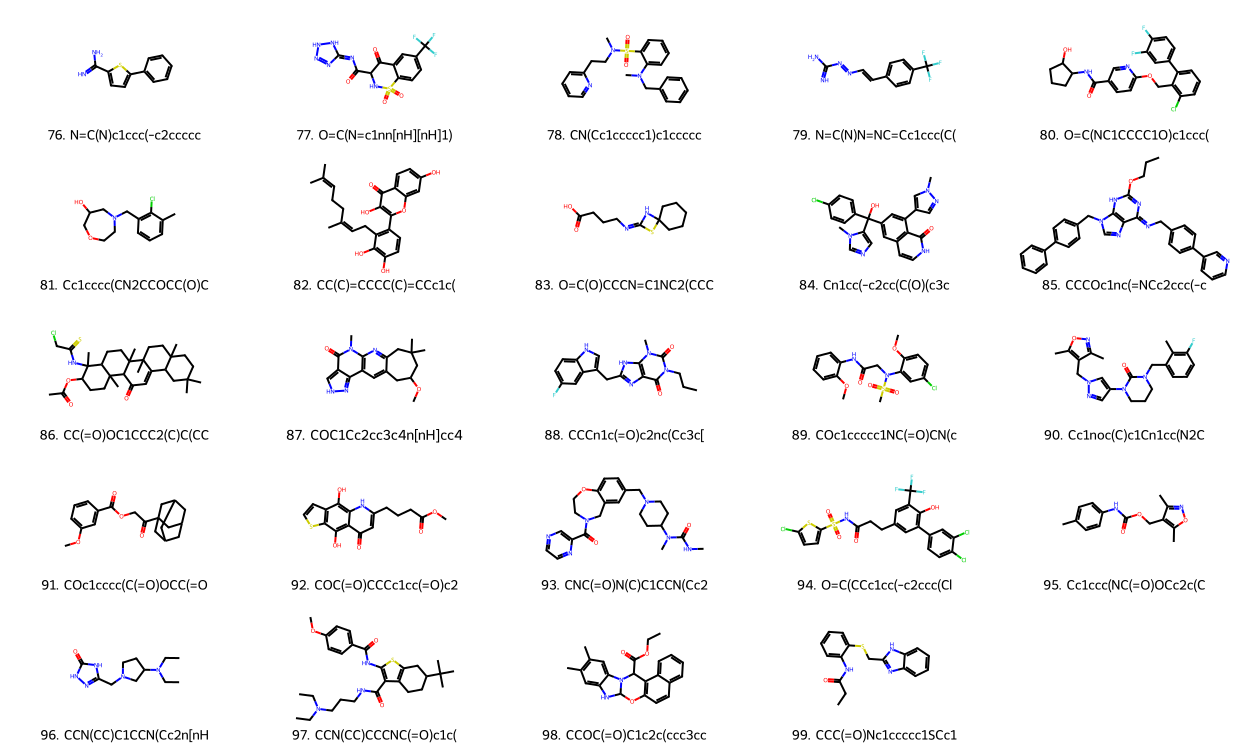


Всего визуализировано 99 валидных молекул


In [40]:
# Визуализация всех молекул
visualize_all_molecules(molecules, mols_per_page=25, img_size=(250, 150))

В принципе все валентности и количество связей в формулах соблюдено - значит можно считать, что всё хорошо.

теперь на валидных молекулах с помощью модели LightGBM предскажем значение pValue.

**!!!**Фингерпринты нужно генерировать заново для каждой новой молекулы, потому что модель LightGBM работает только с числовыми признаками и не хранит информацию о том, как эти признаки были получены. Когда мы обучали модель, мы преобразовали молекулы в фингерпринты.

Для предсказаний новые молекулы должны быть представлены в точно таком же формате. Модель содержит только правила принятия решений (деревья), но не помнит, как исходные молекулы превращались в фингерпринты. Если не генерировать фингерпринты заново тем же способом, модель получит данные в неправильном формате и выдаст некорректные предсказания.

In [41]:
def smiles_to_fingerprint(smiles, radius=2, n_bits=1024): # используем те же пармаетры для фингерпринтов, которые используются в предыдущем датасете
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    fp = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits).GetFingerprint(mol)
    return np.array(fp)

In [42]:
# Генерация фичей и предсказание
valid_mols['fingerprint'] = valid_mols['SMILES'].progress_apply(smiles_to_fingerprint)
X = np.stack(valid_mols['fingerprint'].values)

# Исправленный PCA с проверкой
if model.n_features_ != X.shape[1]:
    # Определяем максимально возможное количество компонент
    max_components = min(X.shape[0], X.shape[1])

    # Берем минимум из нужного и возможного
    n_components = min(model.n_features_, max_components)

    # Применяем PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    # Если нужно, дополняем нулями
    if n_components < model.n_features_:
        padding = np.zeros((X_pca.shape[0], model.n_features_ - n_components))
        X = np.hstack([X_pca, padding])
    else:
        X = X_pca

valid_mols['pValue'] = model.predict(X)

100%|██████████| 99/99 [00:00<00:00, 329.04it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Теперь мы рассчитаем все свойства, которые важно учесть для получения новых лекарственных молекул: насколько сильно молекула имеет сродство к лекарствам, её токсичность, насколько просто её синтезировать и т.д.

In [43]:
# Drug-likeness (QED) - насколько сильное сродство молекулы к лекарству
valid_mols['QED'] = valid_mols['SMILES'].progress_apply(lambda x: QED.qed(Chem.MolFromSmiles(x)))

100%|██████████| 99/99 [00:00<00:00, 384.72it/s]


In [44]:
 # SA Score - насколько легко эту молекулу синтезировать (шкала от 1 до 10)
from rdkit.Contrib.SA_Score import sascorer
valid_mols['SA_Score'] = valid_mols['SMILES'].progress_apply(
        lambda x: sascorer.calculateScore(Chem.MolFromSmiles(x)))

100%|██████████| 99/99 [00:00<00:00, 1128.12it/s]


In [45]:
# Проходимость через ГЭБ (BBB) - используем эмпирические правила: молекулярную массу и липофильность (чем меньше молярная масса и липофильность - тем легче молекула проникает)
valid_mols['BBB'] = valid_mols['SMILES'].progress_apply(
    lambda x: 1 if (Descriptors.MolWt(Chem.MolFromSmiles(x)) < 450 and
                   Descriptors.MolLogP(Chem.MolFromSmiles(x)) < 5) else 0)

100%|██████████| 99/99 [00:00<00:00, 1128.80it/s]


In [46]:
# Токсичность (BRENK фильтры)
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
catalog = FilterCatalog(params)
valid_mols['Toxicophore'] = valid_mols['SMILES'].progress_apply(
    lambda x: 1 if catalog.HasMatch(Chem.MolFromSmiles(x)) else 0)

100%|██████████| 99/99 [00:00<00:00, 1439.54it/s]


In [47]:
# Правила Липинского - будет ли молекула хорошим пероральным лекарством.
def count_lipinski_violations(smiles):
    mol = Chem.MolFromSmiles(smiles)
    violations = 0
    if Descriptors.MolWt(mol) > 500: violations += 1
    if Descriptors.MolLogP(mol) > 5: violations += 1
    if Lipinski.NumHDonors(mol) > 5: violations += 1
    if Lipinski.NumHAcceptors(mol) > 10: violations += 1
    return violations

In [48]:
valid_mols['Lipinski_violations'] = valid_mols['SMILES'].progress_apply(count_lipinski_violations)

100%|██████████| 99/99 [00:00<00:00, 1094.79it/s]


Теперь мы проведём отбор молекул-хитов, которые соответствуют параметрам, указанным в задании выше.

In [49]:
valid_mols

,SMILES,is_valid,fingerprint,pValue,QED,SA_Score,BBB,Toxicophore,Lipinski_violations
0,COC(=O)c1coc(CN2CCN(C(=O)Cc3ccc4c(c3)OCO4)CC2)n1,True,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",6.679488,0.703704,2.388037,1,0,0
1,Cc1ccc(NC(=O)c2ccc(OCCC(F)(F)F)nc2)cc1C(=O)N1C...,True,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",6.632385,0.276005,2.729476,0,0,2
2,O=C(N=c1[nH]c(CN2CCOCC2)cs1)Nc1ccccc1,True,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.663664,0.909710,2.773381,1,0,0
3,Cc1ccc(S(=O)(=O)N2CCN3CCCCC3C2)s1,True,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.399611,0.837606,2.705575,1,0,0
4,CCC(c1ccc([S+](C)[O-])cc1)c1c(C)nc2sc3c(c2c1-c...,True,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.780254,0.277939,3.787619,0,1,1
...,...,...,...,...,...,...,...,...,...
94,Cc1ccc(NC(=O)OCc2c(C)noc2C)cc1,True,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.498210,0.918691,1.914868,1,0,0
95,CCN(CC)C1CCN(Cc2n[nH]c(=O)[nH]2)C1,True,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",6.426727,0.759552,3.346291,1,0,0
96,CCN(CC)CCCNC(=O)c1c(NC(=O)c2ccc(OC)cc2)sc2c1CC...,True,"[0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...",6.150723,0.416277,2.893075,0,1,1
97,CCOC(=O)C1c2c(ccc3ccccc23)OC2Nc3cc(C)c(C)cc3N21,True,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",6.285243,0.660856,3.671662,1,0,0


Удаляем колонку is_valid и fingerprint - они использовались только на промежуточном этапе. В финальный датасет они не пойдут

In [50]:
valid_mols=valid_mols.drop(columns=['is_valid', 'fingerprint'])
valid_mols

,SMILES,pValue,QED,SA_Score,BBB,Toxicophore,Lipinski_violations
0,COC(=O)c1coc(CN2CCN(C(=O)Cc3ccc4c(c3)OCO4)CC2)n1,6.679488,0.703704,2.388037,1,0,0
1,Cc1ccc(NC(=O)c2ccc(OCCC(F)(F)F)nc2)cc1C(=O)N1C...,6.632385,0.276005,2.729476,0,0,2
2,O=C(N=c1[nH]c(CN2CCOCC2)cs1)Nc1ccccc1,6.663664,0.909710,2.773381,1,0,0
3,Cc1ccc(S(=O)(=O)N2CCN3CCCCC3C2)s1,6.399611,0.837606,2.705575,1,0,0
4,CCC(c1ccc([S+](C)[O-])cc1)c1c(C)nc2sc3c(c2c1-c...,6.780254,0.277939,3.787619,0,1,1
...,...,...,...,...,...,...,...
94,Cc1ccc(NC(=O)OCc2c(C)noc2C)cc1,6.498210,0.918691,1.914868,1,0,0
95,CCN(CC)C1CCN(Cc2n[nH]c(=O)[nH]2)C1,6.426727,0.759552,3.346291,1,0,0
96,CCN(CC)CCCNC(=O)c1c(NC(=O)c2ccc(OC)cc2)sc2c1CC...,6.150723,0.416277,2.893075,0,1,1
97,CCOC(=O)C1c2c(ccc3ccccc23)OC2Nc3cc(C)c(C)cc3N21,6.285243,0.660856,3.671662,1,0,0


In [58]:
# отбор молекул, удовлетворяющих следующим критерием
criteria = {
    'pValue': lambda x: x > 6.0,
    'QED': lambda x: x > 0.8,
    'SA_Score': lambda x: 3 < x < 7,
    'BBB': lambda x: x == 1,
    'Toxicophore': lambda x: x == 0,
    'Lipinski_violations': lambda x: x <= 1
}

hits = valid_mols.copy()
for param, condition in criteria.items():
    if param in hits.columns:
        hits = hits[hits[param].apply(condition)]
    else:
        print(f"Предупреждение: столбец {param} не найден")

hits = hits.sort_values('pValue', ascending=False, ignore_index=False)

Теперь сделаем генерацию комментариев, чтобы было проще понять, насколько хорошую молекулу мы получили

In [59]:
def generate_comment(row):
    comments = []
    if row['pValue'] > 7.0: comments.append("High activity")
    if row['QED'] > 0.8: comments.append("Great drug-likeness")
    if 'SA_Score' in row and row['SA_Score'] < 3: comments.append("simple synthesis")
    if row['Lipinski_violations'] == 0: comments.append("Conforms to Lipinsky's rules")
    return "; ".join(comments) if comments else "A promising candidate"

In [60]:
hits['Comment'] = hits.apply(generate_comment, axis=1)

И наконец, мы сделаем финальный датасет с оставшимися молекулами

In [61]:
hits.to_csv('selected_hits.csv')
hits.count()

,0
SMILES,1
pValue,1
QED,1
SA_Score,1
BBB,1
Toxicophore,1
Lipinski_violations,1
Comment,1


#**Вывод**
Получаем, что 1% молекул будет молекулами-хитами. Это говорит о хорошей отфильтрованности